# Lysosome Masking for Hannah Bailey

## Load sample information
This is the sample sheet set up I used

In [44]:
import pandas as pd

samplesheet = pd.read_csv("/Users/kelpschdj/Documents/DataTecnica/Hannah_Bailey/Hannah_RepresentativeImages/hb_samplesheet.csv")
samplesheet

,filename,Treatment,ch0,ch1,ch2,ch3
0,20240729_WT_ACs_pR10_647_Lamp1_568_GFAP488_NG_...,Nigericin,DAPI,GFAP,LAMP1,pRAB10
1,20240729_WT_ACs_pR10_647_Lamp1_568_GFAP488_Unt...,Untreated,DAPI,GFAP,LAMP1,pRAB10
2,20240729_WT_ACs_pR10_647_Lamp1_568_GFAP488_V1_...,Vacuolin-1,DAPI,GFAP,LAMP1,pRAB10
3,20250311_647pR10_488GFAP_561Lamp1_Apilimod_rep...,Apilimod,pRAB10,LAMP1,GFAP,DAPI
4,20250311_647pR10_488GFAP_561Lamp1_Apilimod_rep...,Apilimod,pRAB10,LAMP1,GFAP,DAPI
5,20250311_647pR10_488GFAP_561Lamp1_CQ_200uM2h_r...,Chloroquine,pRAB10,LAMP1,GFAP,DAPI
6,20250311_647pR10_488GFAP_561Lamp1_CQ_200uM2h_r...,Chloroquine,pRAB10,LAMP1,GFAP,DAPI
7,20250311_647pR10_488GFAP_561Lamp1_Mon_Rep1_003...,Monensin,pRAB10,LAMP1,GFAP,DAPI
8,20250311_647pR10_488GFAP_561Lamp1_Mon_Rep1_008...,Monensin,pRAB10,LAMP1,GFAP,DAPI
9,20250311_647pR10_488GFAP_561Lamp1_Mon_Rep1_012...,Monensin,pRAB10,LAMP1,GFAP,DAPI


## Load images

In [ ]:
# Helper function to pull metadata info from image

def get_channel_indices(row, n_channels=4):
    channel_map = {}

    for i in range(n_channels):
        name = row.get(f"ch{i}")
        if name:
            channel_map[name] = i
    return channel_map

def get_image_path(row, img_lookup):
    return img_lookup.get(row["filename"])

In [ ]:
#! Important chunk - here is where you will set the path of your folder of images and call a single image to open

from pathlib import Path

# Define the image directory
img_dir = Path("/Users/kelpschdj/Documents/DataTecnica/Hannah_Bailey/Hannah_RepresentativeImages")
print(img_dir)

imgs = list(sorted(img_dir.glob('*.tif')))
print(imgs)

img_lookup = {p.name: p for p in imgs}

# Define the image that you want to open via changing the number of the image index - this is tied to the order of images in the sample sheet, not the directory
row = samplesheet.iloc[1] #image index
fname = row["filename"]

img_path = img_lookup.get(fname)

samplesheet["image_path"] = samplesheet.apply(
    get_image_path, axis=1, img_lookup=img_lookup
)

ch_index = get_channel_indices(row)

dapi_ch = ch_index["DAPI"]
gfap_ch = ch_index["GFAP"]
lyso_ch = ch_index["LAMP1"]
prab10_ch = ch_index["pRAB10"]

/Users/kelpschdj/Documents/DataTecnica/Hannah_Bailey/Hannah_RepresentativeImages
[PosixPath('/Users/kelpschdj/Documents/DataTecnica/Hannah_Bailey/Hannah_RepresentativeImages/20240729_WT_ACs_pR10_647_Lamp1_568_GFAP488_NG_002_MIP.tif'), PosixPath('/Users/kelpschdj/Documents/DataTecnica/Hannah_Bailey/Hannah_RepresentativeImages/20240729_WT_ACs_pR10_647_Lamp1_568_GFAP488_Unt010_MIP.tif'), PosixPath('/Users/kelpschdj/Documents/DataTecnica/Hannah_Bailey/Hannah_RepresentativeImages/20240729_WT_ACs_pR10_647_Lamp1_568_GFAP488_V1_006_MIP.tif'), PosixPath('/Users/kelpschdj/Documents/DataTecnica/Hannah_Bailey/Hannah_RepresentativeImages/20250311_647pR10_488GFAP_561Lamp1_Apilimod_rep1_022_MIP.tif'), PosixPath('/Users/kelpschdj/Documents/DataTecnica/Hannah_Bailey/Hannah_RepresentativeImages/20250311_647pR10_488GFAP_561Lamp1_Apilimod_rep1_023_MIP.tif'), PosixPath('/Users/kelpschdj/Documents/DataTecnica/Hannah_Bailey/Hannah_RepresentativeImages/20250311_647pR10_488GFAP_561Lamp1_CQ_200uM2h_rep1_010_MIP

## Read an image

In [47]:
import tifffile 
import os

img = tifffile.imread(img_path)

print(img)
print(img.shape)

[[[ 109  107  110 ...  107  106  107]
  [ 107  108  108 ...  111  109  106]
  [ 107  107  106 ...  108  105  105]
  ...
  [ 110  109  109 ...  103  106  106]
  [ 106  106  104 ...  104  105  108]
  [ 104  105  107 ...  105  104  105]]

 [[ 160  143  142 ... 1429 1599 1763]
  [ 150  138  160 ... 1501 1640 1813]
  [ 153  157  160 ... 1607 1705 1799]
  ...
  [ 116  114  113 ...  303  377  440]
  [ 110  116  113 ...  236  297  372]
  [ 114  120  114 ...  200  216  263]]

 [[ 108  107  110 ...  109  110  117]
  [ 104  104  107 ...  114  115  111]
  [ 106  109  111 ...  112  107  106]
  ...
  [ 109  107  103 ...  105  105  109]
  [ 103  108  104 ...  109  108  108]
  [ 105  103  107 ...  105  110  106]]

 [[ 117  117  116 ...  110  116  116]
  [ 119  112  122 ...  113  117  119]
  [ 123  110  114 ...  112  114  117]
  ...
  [ 109  112  106 ...  104  112  106]
  [ 104  104  103 ...  107  107  106]
  [ 105  104  105 ...  105  106  113]]]
(4, 1200, 1200)


## Preview an image
This will open the image series in napari with each channel labelled

In [48]:
import napari

viewer = napari.Viewer()

viewer.add_image(img[dapi_ch], 
                 name='DAPI',
                 blending="additive",
                 colormap="blue"
                 )

viewer.add_image(img[gfap_ch], 
                 name='GFAP',
                 blending="additive",
                 colormap="green"
                 )

viewer.add_image(img[lyso_ch], 
                 name='LAMP1',
                 blending="additive",
                 colormap="red")

viewer.add_image(img[prab10_ch], 
                 name='pRAB10',
                 blending="additive",
                 colormap="magenta")

<Image layer 'pRAB10' at 0x500ec9310>

This will generate a plot with the labelled image series\
I commented out a line so you can save this image if you want

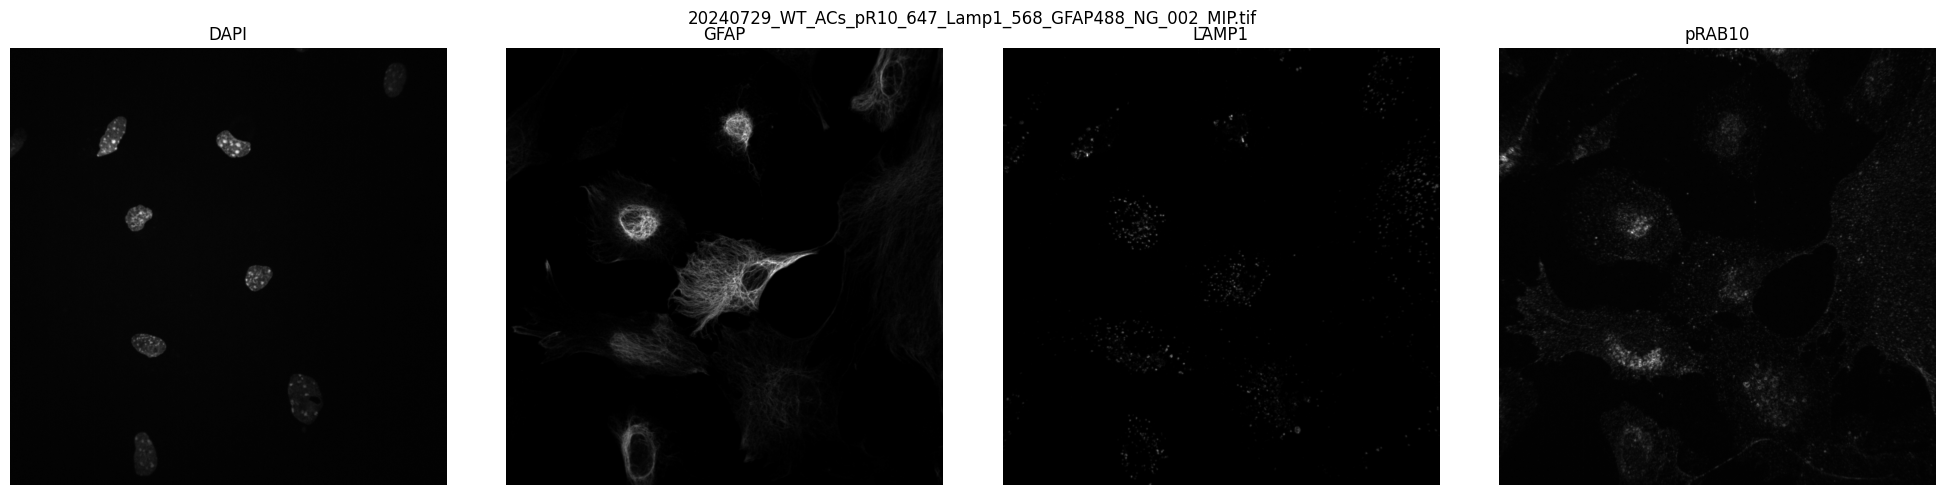

In [49]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(os.path.basename(img_path))

axs[0].imshow(img[dapi_ch], cmap='gray') 
axs[0].set_title("DAPI")
axs[0].axis("off")

axs[1].imshow(img[gfap_ch], cmap = "gray")
axs[1].set_title("GFAP")
axs[1].axis("off")

axs[2].imshow(img[lyso_ch], cmap='gray')
axs[2].set_title("LAMP1")
axs[2].axis("off")

axs[3].imshow(img[prab10_ch], cmap='gray')
axs[3].set_title("pRAB10")
axs[3].axis("off")

plt.tight_layout()
plt.show()

## Identify nuclei and cell boundaries
runs cellpose on dapi and gfap channels

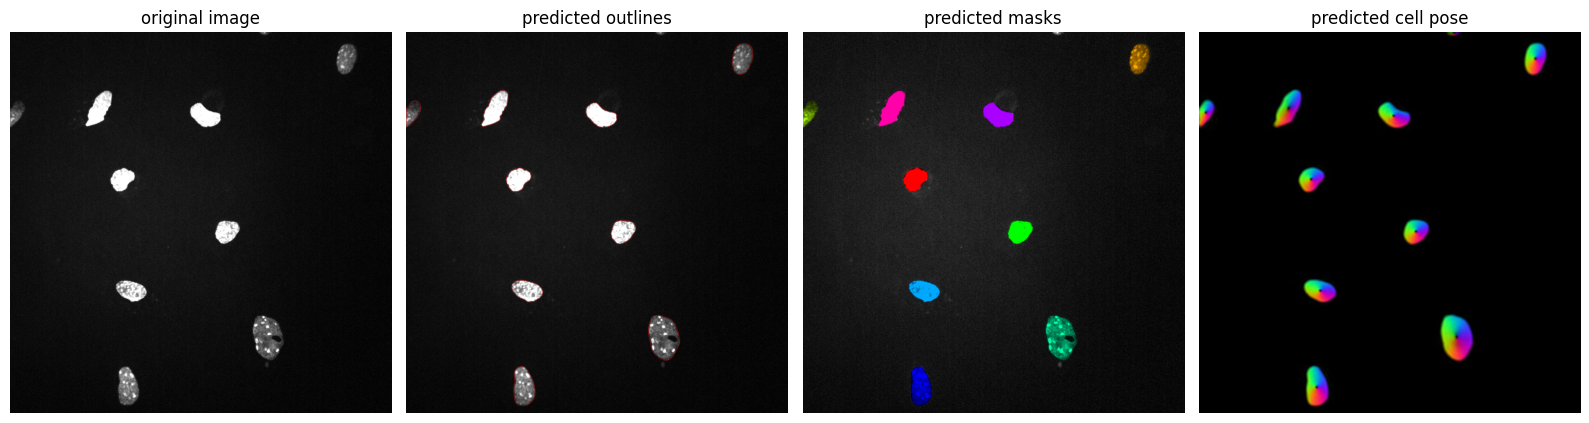

In [ ]:
# nuclei

from cellpose import models, core, io, plot

flow_threshold = 0.4
cellprob_threshold = 0.0
tile_norm_blocksize = 0

#io.logger_setup() # run this to get printing of progress

model = models.CellposeModel(gpu=True)

cellpose_nuc_masks, flows, styles = model.eval(
    img[dapi_ch],
    batch_size=32, 
    diameter=120, 
    flow_threshold=flow_threshold, 
    cellprob_threshold=cellprob_threshold,
    normalize={"tile_norm_blocksize": tile_norm_blocksize}
    )

fig = plt.figure(figsize=(16,10))
plot.show_segmentation(fig, img[dapi_ch], cellpose_nuc_masks, flows[0])
plt.tight_layout()
plt.show()

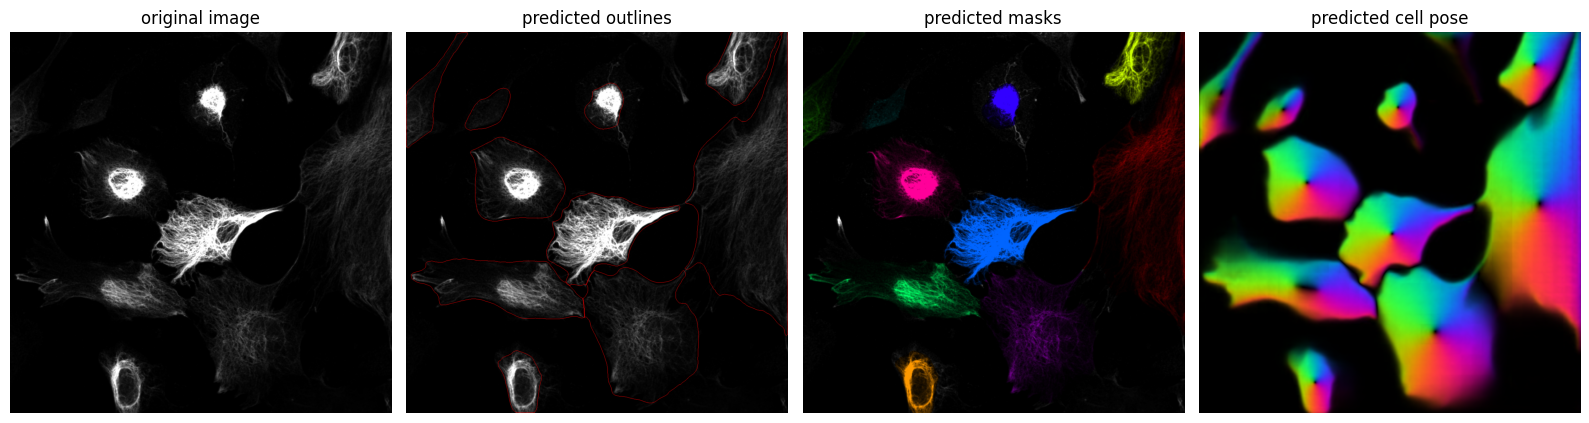

In [ ]:
# cells

import numpy as np
from cellpose import models, core, io, plot

flow_threshold = 0.4
cellprob_threshold = 0.0
tile_norm_blocksize = 0

#io.logger_setup() # run this to get printing of progress

model = models.CellposeModel(gpu=True)

stack = np.stack([img[dapi_ch], img[gfap_ch]], axis=0)

cellpose_cell_masks, flows, styles = model.eval(
    stack,
    batch_size=32, 
    diameter=120, 
    flow_threshold=flow_threshold, 
    cellprob_threshold=cellprob_threshold,
    normalize={"tile_norm_blocksize": tile_norm_blocksize}
    )

fig = plt.figure(figsize=(16,10))
plot.show_segmentation(fig, stack, cellpose_cell_masks, flows[0])
plt.tight_layout()
plt.show()

In [ ]:
# view channels and cellpose masks via napari

import napari

viewer = napari.Viewer()

viewer.add_image(img[dapi_ch], 
                 name='DAPI',
                 blending="additive",
                 colormap="blue"
                 )

viewer.add_image(img[gfap_ch], 
                 name='GFAP',
                 blending="additive",
                 colormap="green"
                 )

viewer.add_image(img[lyso_ch], 
                 name='LAMP1',
                 blending="additive",
                 colormap="red")

viewer.add_image(img[prab10_ch], 
                 name='pRAB10',
                 blending="additive",
                 colormap="magenta")

viewer.add_labels(cellpose_nuc_masks,
                  name = "Nucleus mask")

viewer.add_labels(cellpose_cell_masks,
                  name = "Cell mask")

<Labels layer 'Cell mask' at 0x513a81810>

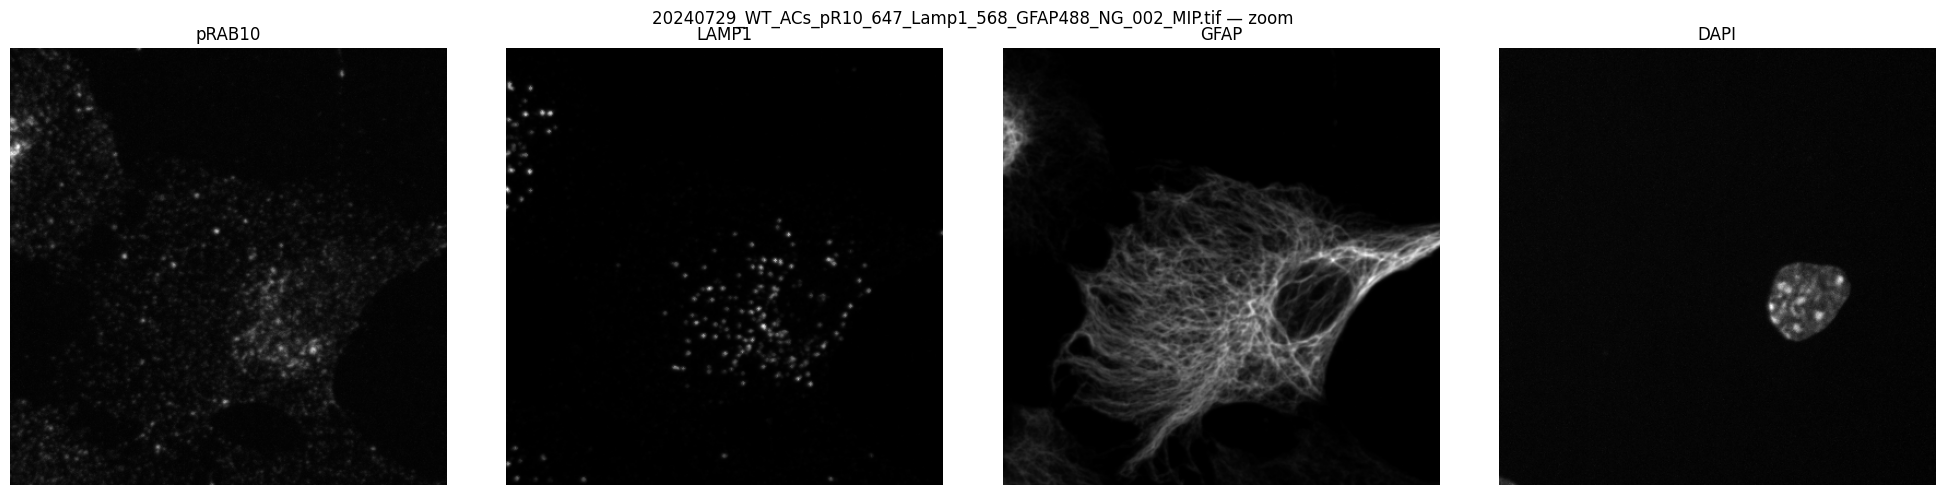

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(f"{os.path.basename(img_path)} — zoom")

axs[0].imshow(img[prab10_ch, 400:800, 400:800], cmap='gray') # you can change the location of zoom by modifying the values 400:800, 400:800
axs[0].set_title("pRAB10")
axs[0].axis("off")

axs[1].imshow(img[lyso_ch, 400:800, 400:800], cmap = "gray")
axs[1].set_title("LAMP1")
axs[1].axis("off")

axs[2].imshow(img[gfap_ch, 400:800, 400:800], cmap='gray')
axs[2].set_title("GFAP")
axs[2].axis("off")

axs[3].imshow(img[dapi_ch, 400:800, 400:800], cmap='gray')
axs[3].set_title("DAPI")
axs[3].axis("off")

plt.tight_layout()
plt.show()

### ID lysosomes from a single image

In [54]:
from scipy.ndimage import gaussian_laplace
from skimage import filters, morphology
from scipy import ndimage as ndi
import numpy as np
from scipy.stats import norm

# Paramaters - same as ACIS standard
intensity_scaling_param = [3, 12]
min_lysosome_area = 5
blur_sigma = 1
log_sigma_1, log_cutoff_1 = 3, 0.07
log_sigma_2, log_cutoff_2 = 2, 0.06
log_sigma_3, log_cutoff_3 = 1, 0.04
vesselness_sigma = [1]
vesselness_cutoff = 0.03

lys_ch = img[lyso_ch].copy().astype(float)

# Normalize to normal distribution
m, s = norm.fit(lys_ch.flatten())
stretch_min = max(m - intensity_scaling_param[0] * s, lys_ch.min())
stretch_max = min(m + intensity_scaling_param[1] * s, lys_ch.max())
lys_ch_n = np.clip(lys_ch, stretch_min, stretch_max)
image_norm = (lys_ch_n - stretch_min) / (stretch_max - stretch_min)

# Blur image
blurred = filters.gaussian(image_norm, sigma=blur_sigma)

# Identify blobs
log_1 = -1 * (log_sigma_1**2) * gaussian_laplace(blurred, sigma=log_sigma_1)
log_2 = -1 * (log_sigma_2**2) * gaussian_laplace(blurred, sigma=log_sigma_2)
log_3 = -1 * (log_sigma_3**2) * gaussian_laplace(blurred, sigma=log_sigma_3)

log_1_mask = log_1 > log_cutoff_1
log_2_mask = log_2 > log_cutoff_2
log_3_mask = log_3 > log_cutoff_3

log_mask = np.logical_or(log_1_mask, log_2_mask)
log_mask = np.logical_or(log_mask, log_3_mask)

# Identify vessels
vesselness = filters.frangi(blurred, sigmas=vesselness_sigma, black_ridges=False) > vesselness_cutoff
combined = np.logical_or(log_mask, vesselness)

filled = ndi.binary_fill_holes(combined)
lysosome_mask = morphology.remove_small_objects(filled, min_size=min_lysosome_area)

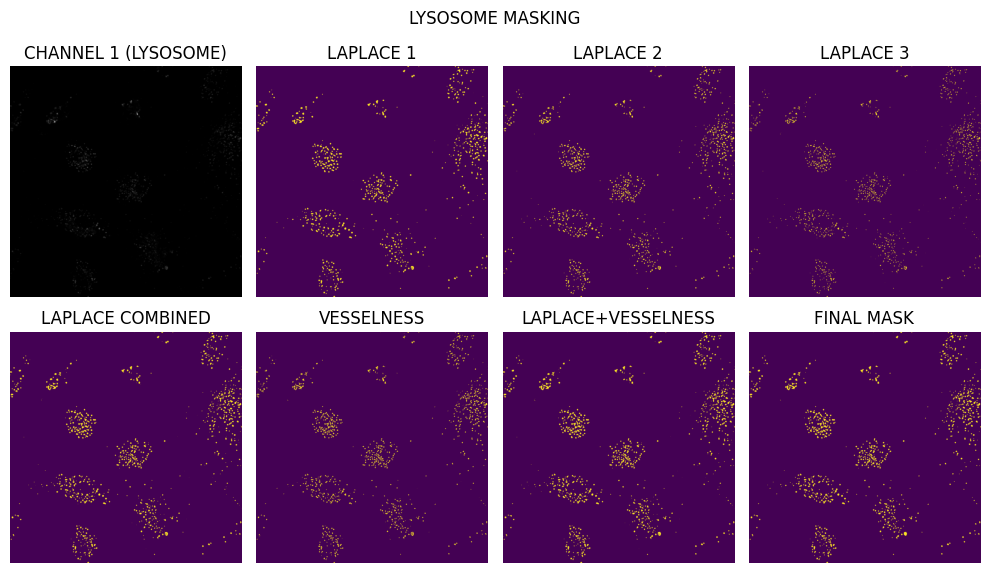

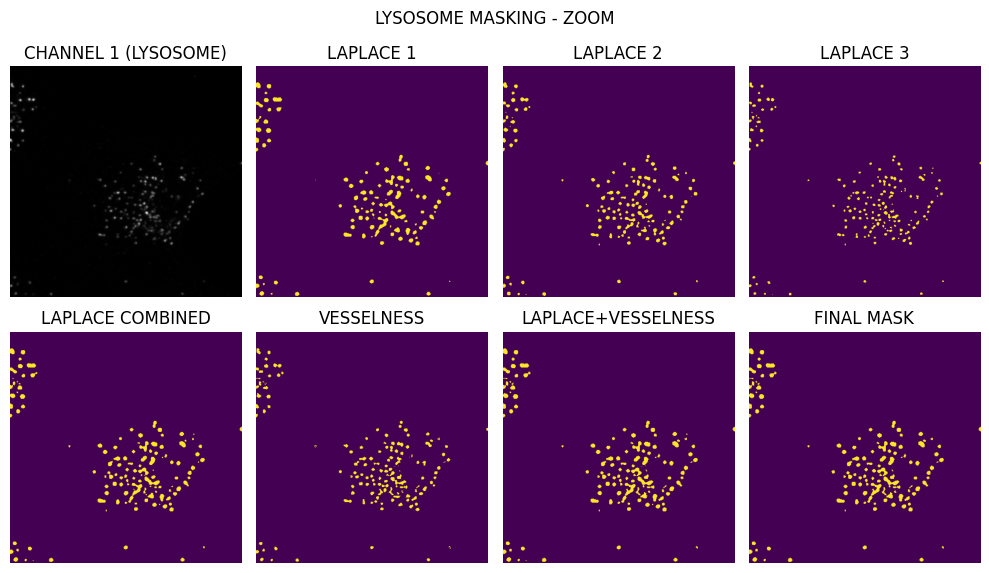

In [55]:
fig, axs = plt.subplots(2, 4, figsize=(10, 6))
fig.suptitle("LYSOSOME MASKING")

axs[0,0].imshow(img[lyso_ch], cmap='gray')
axs[0,0].set_title("CHANNEL 1 (LYSOSOME)")
axs[0,0].axis("off")

axs[0,1].imshow(log_1_mask)
axs[0,1].set_title("LAPLACE 1")
axs[0,1].axis("off")

axs[0,2].imshow(log_2_mask)
axs[0,2].set_title("LAPLACE 2")
axs[0,2].axis("off")

axs[0,3].imshow(log_3_mask)
axs[0,3].set_title("LAPLACE 3")
axs[0,3].axis("off")

axs[1,0].imshow(log_mask)
axs[1,0].set_title("LAPLACE COMBINED")
axs[1,0].axis("off")

axs[1,1].imshow(vesselness)
axs[1,1].set_title("VESSELNESS")
axs[1,1].axis("off")

axs[1,2].imshow(combined)
axs[1,2].set_title("LAPLACE+VESSELNESS")
axs[1,2].axis("off")

axs[1,3].imshow(lysosome_mask)
axs[1,3].set_title("FINAL MASK")
axs[1,3].axis("off")

#plt.savefig("lysosome_mask_processing.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(2, 4, figsize=(10, 6))
fig.suptitle("LYSOSOME MASKING - ZOOM")

axs[0,0].imshow(img[lyso_ch, 400:800, 400:800], cmap='gray')
axs[0,0].set_title("CHANNEL 1 (LYSOSOME)")
axs[0,0].axis("off")

axs[0,1].imshow(log_1_mask[400:800, 400:800])
axs[0,1].set_title("LAPLACE 1")
axs[0,1].axis("off")

axs[0,2].imshow(log_2_mask[400:800, 400:800])
axs[0,2].set_title("LAPLACE 2")
axs[0,2].axis("off")

axs[0,3].imshow(log_3_mask[400:800, 400:800])
axs[0,3].set_title("LAPLACE 3")
axs[0,3].axis("off")

axs[1,0].imshow(log_mask[400:800, 400:800])
axs[1,0].set_title("LAPLACE COMBINED")
axs[1,0].axis("off")

axs[1,1].imshow(vesselness[400:800, 400:800])
axs[1,1].set_title("VESSELNESS")
axs[1,1].axis("off")

axs[1,2].imshow(combined[400:800, 400:800])
axs[1,2].set_title("LAPLACE+VESSELNESS")
axs[1,2].axis("off")

axs[1,3].imshow(lysosome_mask[400:800, 400:800])
axs[1,3].set_title("FINAL MASK")
axs[1,3].axis("off")

#plt.savefig("lysosome_mask_processing.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [56]:
import napari

viewer = napari.Viewer()

viewer.add_image(img[dapi_ch], 
                 name='DAPI',
                 blending="additive",
                 colormap="blue"
                 )

viewer.add_image(img[gfap_ch], 
                 name='GFAP',
                 blending="additive",
                 colormap="green"
                 )

viewer.add_image(img[lyso_ch], 
                 name='LAMP1',
                 blending="additive",
                 colormap="red")

viewer.add_image(img[prab10_ch], 
                 name='pRAB10',
                 blending="additive",
                 colormap="magenta")

viewer.add_labels(cellpose_nuc_masks,
                  name = "Nucleus mask")

viewer.add_labels(cellpose_cell_masks,
                  name = "Cell mask")

viewer.add_labels(lysosome_mask, 
                 name='LYSOSOME MASK')

<Labels layer 'LYSOSOME MASK' at 0x38b6d8690>

### ID pRAB10 from a single image

In [57]:
from scipy.ndimage import gaussian_laplace
from skimage import filters, morphology
from scipy import ndimage as ndi
import numpy as np
from scipy.stats import norm

# Paramaters - same as ACIS standard
intensity_scaling_param = [1, 9]
min_prab10_area = 5
blur_sigma = 1
log_sigma_1, log_cutoff_1 = 3, 0.07
log_sigma_2, log_cutoff_2 = 2, 0.04
log_sigma_3, log_cutoff_3 = 1, 0.01
vesselness_sigma = [1]
vesselness_cutoff = 0.05

prab_ch = img[prab10_ch].copy().astype(float)

# Normalize image
#image_norm = (prab_ch - np.min(prab_ch)) / (np.max(prab_ch) - np.min(prab_ch))

# Normalize to normal distribution
m, s = norm.fit(prab_ch.flatten())
stretch_min = max(m - intensity_scaling_param[0] * s, prab_ch.min())
stretch_max = min(m + intensity_scaling_param[1] * s, prab_ch.max())
prab_ch_n = np.clip(prab_ch, stretch_min, stretch_max)
image_norm = (prab_ch_n - stretch_min) / (stretch_max - stretch_min)

# Blur image
blurred = filters.gaussian(image_norm, sigma=blur_sigma)

# Identify blobs
log_1 = -1 * (log_sigma_1**2) * gaussian_laplace(blurred, sigma=log_sigma_1)
log_2 = -1 * (log_sigma_2**2) * gaussian_laplace(blurred, sigma=log_sigma_2)
log_3 = -1 * (log_sigma_3**2) * gaussian_laplace(blurred, sigma=log_sigma_3)

log_1_mask = log_1 > log_cutoff_1
log_2_mask = log_2 > log_cutoff_2
log_3_mask = log_3 > log_cutoff_3

log_mask = np.logical_or(log_1_mask, log_2_mask)
log_mask = np.logical_or(log_mask, log_3_mask)

# Identify vessels
vesselness = filters.frangi(blurred, sigmas=vesselness_sigma, black_ridges=False) > vesselness_cutoff
combined = np.logical_or(log_mask, vesselness)

## add a watershed?

filled = ndi.binary_fill_holes(combined)
prab10_mask = morphology.remove_small_objects(filled, min_size=min_prab10_area)

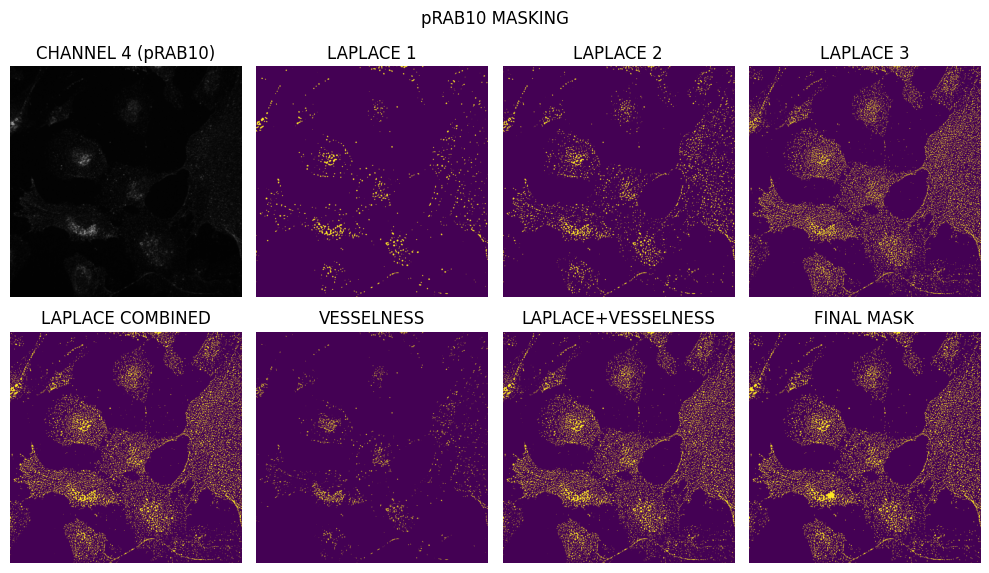

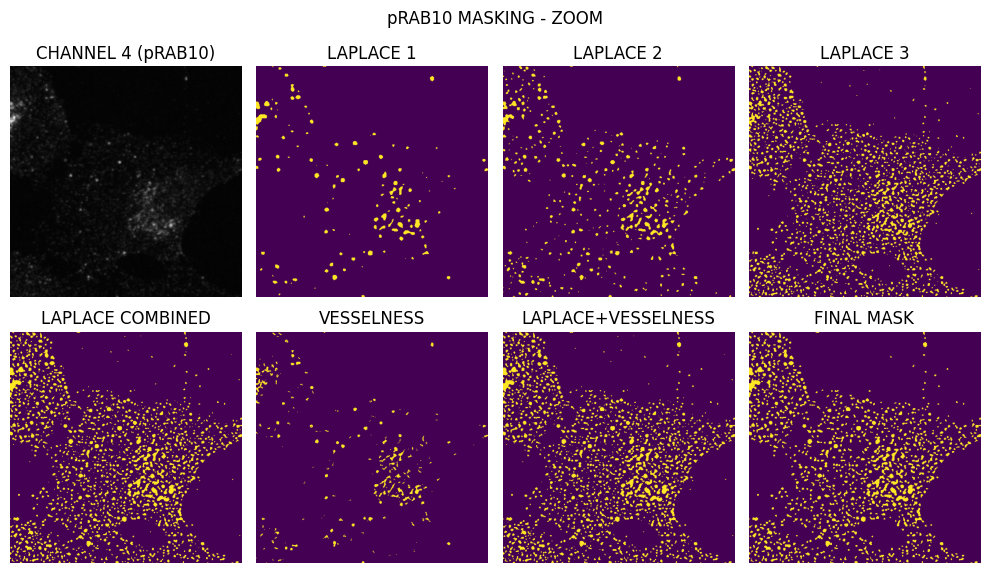

In [58]:
fig, axs = plt.subplots(2, 4, figsize=(10, 6))
fig.suptitle("pRAB10 MASKING")

axs[0,0].imshow(img[prab10_ch], cmap='gray')
axs[0,0].set_title("CHANNEL 4 (pRAB10)")
axs[0,0].axis("off")

axs[0,1].imshow(log_1_mask)
axs[0,1].set_title("LAPLACE 1")
axs[0,1].axis("off")

axs[0,2].imshow(log_2_mask)
axs[0,2].set_title("LAPLACE 2")
axs[0,2].axis("off")

axs[0,3].imshow(log_3_mask)
axs[0,3].set_title("LAPLACE 3")
axs[0,3].axis("off")

axs[1,0].imshow(log_mask)
axs[1,0].set_title("LAPLACE COMBINED")
axs[1,0].axis("off")

axs[1,1].imshow(vesselness)
axs[1,1].set_title("VESSELNESS")
axs[1,1].axis("off")

axs[1,2].imshow(combined)
axs[1,2].set_title("LAPLACE+VESSELNESS")
axs[1,2].axis("off")

axs[1,3].imshow(prab10_mask)
axs[1,3].set_title("FINAL MASK")
axs[1,3].axis("off")

#plt.savefig("pRAB10_mask_processing.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(2, 4, figsize=(10, 6))
fig.suptitle("pRAB10 MASKING - ZOOM")

axs[0,0].imshow(img[prab10_ch, 400:800, 400:800], cmap='gray')
axs[0,0].set_title("CHANNEL 4 (pRAB10)")
axs[0,0].axis("off")

axs[0,1].imshow(log_1_mask[400:800, 400:800])
axs[0,1].set_title("LAPLACE 1")
axs[0,1].axis("off")

axs[0,2].imshow(log_2_mask[400:800, 400:800])
axs[0,2].set_title("LAPLACE 2")
axs[0,2].axis("off")

axs[0,3].imshow(log_3_mask[400:800, 400:800])
axs[0,3].set_title("LAPLACE 3")
axs[0,3].axis("off")

axs[1,0].imshow(log_mask[400:800, 400:800])
axs[1,0].set_title("LAPLACE COMBINED")
axs[1,0].axis("off")

axs[1,1].imshow(vesselness[400:800, 400:800])
axs[1,1].set_title("VESSELNESS")
axs[1,1].axis("off")

axs[1,2].imshow(combined[400:800, 400:800])
axs[1,2].set_title("LAPLACE+VESSELNESS")
axs[1,2].axis("off")

axs[1,3].imshow(prab10_mask[400:800, 400:800])
axs[1,3].set_title("FINAL MASK")
axs[1,3].axis("off")

#plt.savefig("lysosome_mask_processing.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [59]:
import napari

viewer = napari.Viewer()

viewer.add_image(img[dapi_ch], 
                 name='DAPI',
                 blending="additive",
                 colormap="blue"
                 )

viewer.add_image(img[gfap_ch], 
                 name='GFAP',
                 blending="additive",
                 colormap="green"
                 )

viewer.add_image(img[lyso_ch], 
                 name='LAMP1',
                 blending="additive",
                 colormap="red")

viewer.add_image(img[prab10_ch], 
                 name='pRAB10',
                 blending="additive",
                 colormap="magenta")

viewer.add_labels(cellpose_nuc_masks,
                  name = "Nucleus mask")

viewer.add_labels(cellpose_cell_masks,
                  name = "Cell mask")

viewer.add_labels(lysosome_mask, 
                 name='LYSOSOME MASK')

viewer.add_labels(prab10_mask, 
                 name='PRAB10 MASK')

<Labels layer 'PRAB10 MASK' at 0x52872d810>

## Lysosome and pRab10 feature extraction 

In [ ]:
import numpy as np
from scipy import ndimage as ndi
from skimage.measure import label, regionprops_table
import pandas as pd
 
cell_ids = np.unique(cellpose_cell_masks)
cell_ids = cell_ids[cell_ids != 0]

lys_labels_global = np.zeros_like(lysosome_mask, dtype=np.int32)
prab_labels_global = np.zeros_like(prab10_mask, dtype=np.int32)

lys_parent_cell = {}
prab_parent_cell = {}

lys_current_label = 1
prab_current_label = 1

for cid in cell_ids:
    single_cell_mask = (cellpose_cell_masks == cid)

    lys_in_cell = (lysosome_mask > 0) & single_cell_mask
    prab_in_cell = (prab10_mask > 0) & single_cell_mask

    lys_labeled_in_cell, lys_n = ndi.label(lys_in_cell)
    prab_labeled_in_cell, prab_n = ndi.label(prab_in_cell)

    if lys_n > 0:
        for ll in np.unique(lys_labeled_in_cell)[1:]:
            lys_labels_global[lys_labeled_in_cell == ll] = lys_current_label
            lys_parent_cell[lys_current_label] = int(cid)
            lys_current_label += 1

    # write prab10 objects into global label image + mapping
    if prab_n > 0:
        for ll in np.unique(prab_labeled_in_cell)[1:]:
            prab_labels_global[prab_labeled_in_cell == ll] = prab_current_label
            prab_parent_cell[prab_current_label] = int(cid)
            prab_current_label += 1

lys_int = img[lyso_ch] 
prab_int = img[prab10_ch] 

# We can consider changes to the regtion props table - think of this as similar to the measurments window in FIJI
# see documentation for more info!
# https://scikit-image.org/docs/0.25.x/api/skimage.measure.html#skimage.measure.regionprops_table

# Lysosomes
lys_props = regionprops_table(
    lys_labels_global,
    intensity_image=lys_int,
    properties=("label", "area", "min_intensity", "mean_intensity", "max_intensity")
)
lys_df = pd.DataFrame(lys_props)
lys_df["cell_id"] = lys_df["label"].map(lys_parent_cell)

# PRAB10
prab_props = regionprops_table(
    prab_labels_global,
    intensity_image=prab_int,
    properties=("label", "area", "min_intensity", "mean_intensity", "max_intensity")
)
prab_df = pd.DataFrame(prab_props)
prab_df["cell_id"] = prab_df["label"].map(prab_parent_cell)

lys_df.insert(0, "image_id", os.path.basename(img_path))
prab_df.insert(0, "image_id", os.path.basename(img_path))

print(lys_df)
print(prab_df)

                                              image_id  label   area  \
0    20240729_WT_ACs_pR10_647_Lamp1_568_GFAP488_NG_...      1   23.0   
1    20240729_WT_ACs_pR10_647_Lamp1_568_GFAP488_NG_...      2   43.0   
2    20240729_WT_ACs_pR10_647_Lamp1_568_GFAP488_NG_...      3   18.0   
3    20240729_WT_ACs_pR10_647_Lamp1_568_GFAP488_NG_...      4  163.0   
4    20240729_WT_ACs_pR10_647_Lamp1_568_GFAP488_NG_...      5   35.0   
..                                                 ...    ...    ...   
702  20240729_WT_ACs_pR10_647_Lamp1_568_GFAP488_NG_...    703   22.0   
703  20240729_WT_ACs_pR10_647_Lamp1_568_GFAP488_NG_...    704   55.0   
704  20240729_WT_ACs_pR10_647_Lamp1_568_GFAP488_NG_...    705   10.0   
705  20240729_WT_ACs_pR10_647_Lamp1_568_GFAP488_NG_...    706   23.0   
706  20240729_WT_ACs_pR10_647_Lamp1_568_GFAP488_NG_...    707   23.0   

     min_intensity  mean_intensity  max_intensity  cell_id  
0            243.0      353.130435          509.0        1  
1            

In [61]:
import napari

viewer = napari.Viewer()

viewer.add_image(img[dapi_ch], 
                 name='DAPI',
                 blending="additive",
                 colormap="blue"
                 )

viewer.add_image(img[gfap_ch], 
                 name='GFAP',
                 blending="additive",
                 colormap="green"
                 )

viewer.add_image(img[lyso_ch], 
                 name='LAMP1',
                 blending="additive",
                 colormap="red")

viewer.add_image(img[prab10_ch], 
                 name='pRAB10',
                 blending="additive",
                 colormap="magenta")

viewer.add_labels(cellpose_nuc_masks,
                  name = "Nucleus mask")

viewer.add_labels(cellpose_cell_masks,
                  name = "Cell mask")

viewer.add_labels(lys_labels_global, 
                 name='LYSOSOME MASK')

viewer.add_labels(prab_labels_global, 
                 name='PRAB10 MASK')

<Labels layer 'PRAB10 MASK' at 0x50ea51f90>

## Lysosome and pRab10 colocalization data extraction

In [43]:
import numpy as np
import pandas as pd
from skimage.filters import threshold_otsu

lys = img[lyso_ch].astype(np.float64)
prab = img[prab10_ch].astype(np.float64)

cell_ids = np.unique(cellpose_cell_masks)
cell_ids = cell_ids[cell_ids != 0]

rows = []
min_pixels = 50  # skip tiny masks

for cid in cell_ids:
    m = (cellpose_cell_masks == cid)
    npx = int(m.sum())
    if npx < min_pixels:
        continue

    a = lys[m]
    b = prab[m]

    # Pearson r (guard constant arrays)
    if a.std() == 0 or b.std() == 0:
        pearson_r = np.nan
    else:
        pearson_r = float(np.corrcoef(a, b)[0, 1])

    # per-cell Otsu threshold
    try:
        tA = threshold_otsu(a) if np.unique(a).size > 1 else 0.0
    except Exception:
        tA = 0.0
    try:
        tB = threshold_otsu(b) if np.unique(b).size > 1 else 0.0
    except Exception:
        tB = 0.0

    a_pos = a > tA
    b_pos = b > tB

    denomA = a[a_pos].sum()
    denomB = b[b_pos].sum()

    M1 = float(a[a_pos & b_pos].sum() / denomA) if denomA > 0 else np.nan  # lys in prab
    M2 = float(b[b_pos & a_pos].sum() / denomB) if denomB > 0 else np.nan  # prab in lys

    rows.append({
        "cell_id": int(cid),
        "cell_pixels": npx,
        "pearson_r": pearson_r,
        "manders_M1_lys_in_prab": M1,
        "manders_M2_prab_in_lys": M2,
        "theshold_cutoff_lys": float(tA),
        "threshold_cutoff_prab": float(tB),
    })

cell_coloc_df = pd.DataFrame(rows)
cell_coloc_df.insert(0, "image_id", os.path.basename(img_path))

print(cell_coloc_df)



                                            image_id  cell_id  cell_pixels  \
0  20240729_WT_ACs_pR10_647_Lamp1_568_GFAP488_Unt...        1        86367   
1  20240729_WT_ACs_pR10_647_Lamp1_568_GFAP488_Unt...        2        57102   
2  20240729_WT_ACs_pR10_647_Lamp1_568_GFAP488_Unt...        3       149584   

   pearson_r  manders_M1_lys_in_prab  manders_M2_prab_in_lys  \
0   0.129634                0.413076                0.043802   
1   0.149049                0.244164                0.098392   
2   0.134195                0.451080                0.038893   

   theshold_cutoff_lys  threshold_cutoff_prab  
0           642.804688             121.806641  
1           463.261719             126.921875  
2           653.605469             119.458984  
